0.048


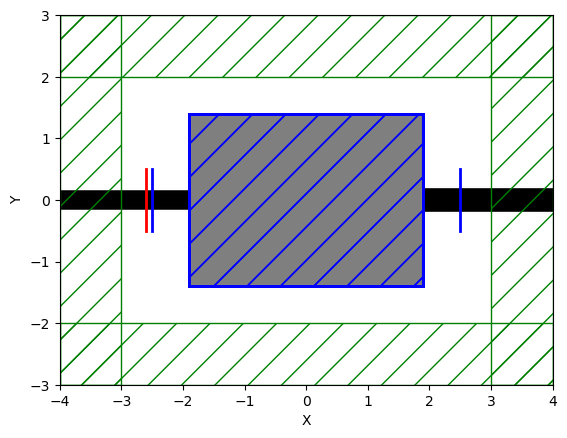

In [13]:
## mode converter ##
import meep as mp
import meep.adjoint as mpa
import numpy as np
from autograd import numpy as npa
from autograd import tensor_jacobian_product as vjp
from autograd import grad as ag_grad
import nlopt
import matplotlib.pyplot as plt

mp.verbosity(0)

Si = mp.Medium(index=3.4)

resolution = 60

# cell size
Sx = 8
Sy = 6
cell_size = mp.Vector3(Sx, Sy, 0)
pml_layers = [mp.PML(1.0)]
 

# source
fcen = 1 / 0.3875 # 387.5nm
width = 0.2
fwidth = width * fcen
source_center = [-2.6, 0, 0]
source_size = mp.Vector3(0, 1, 0)
src = mp.GaussianSource(frequency = fcen, fwidth=fwidth)
source = [
    mp.EigenModeSource(
        src,
        eig_band=1,
        eig_match_freq=True,
        direction=mp.X,
        size=source_size,
        center=source_center,
        eig_parity=mp.ODD_Z
    )
]


# design region
Dx = 3.8
Dy = 2.8
design_region_resolution = int(resolution)

Nx = int(Dx * design_region_resolution + 1)
Ny = int(Dy * design_region_resolution + 1)

design_variables = mp.MaterialGrid(mp.Vector3(Nx, Ny),
                                   mp.air,
                                   Si,
                                   grid_type="U_MEAN")
design_region = mpa.DesignRegion(design_variables,
                                 volume=mp.Volume(center=mp.Vector3(),
                                                  size=mp.Vector3(Dx, Dy)))


# geometry 
geometry = [
    mp.Block(
            center=mp.Vector3(-2.95, 0),
            material=Si,
            size=mp.Vector3(2.1, 0.3, 0)
            ),
    mp.Block(
            center=mp.Vector3(2.95, 0),
            material=Si,
            size=mp.Vector3(2.1, 0.4, 0)
            ),
    mp.Block(
            center=design_region.center,
            material=design_variables,
            size=design_region.size
            )
]


# filter
filter_radius = 0.048
eta_i = (0.5)
eta_e = 0.95
eta_d = 1 - eta_e
print(filter_radius)

def mapping(x, beta, eta):
    x_reshaped = npa.reshape(x, (Nx, Ny))

    # cone shaped filter
    x_filtered = mpa.conic_filter(
        x_reshaped, 
        filter_radius, 
        design_region.size.x,
        design_region.size.y,
        design_region_resolution
    )

    # projection
    x_proj = mpa.tanh_projection(x_filtered, beta, eta)

    return x_proj.flatten()


# simulation
sim =mp.Simulation(
    cell_size=cell_size,
    boundary_layers=pml_layers,
    geometry=geometry,
    sources=source,
    resolution=resolution,
)


# objective function
TE00 = mpa.EigenmodeCoefficient(
    sim,
    mp.Volume(center=mp.Vector3(-2.5,0,0), size=mp.Vector3(y=1)),
    mode=1,
    eig_parity=mp.ODD_Z
)

TE20 = mpa.EigenmodeCoefficient(
    sim,
    mp.Volume(center=mp.Vector3(2.5,0,0), size=mp.Vector3(y=1)),
    mode=3,
    eig_parity=mp.ODD_Z
)

ob_list = [TE00, TE20]

def J(source, monitor):
    return npa.abs(monitor) ** 2 / npa.abs(source) ** 2


opt = mpa.OptimizationProblem(
    simulation=sim,
    objective_functions=[J],
    objective_arguments=ob_list,
    design_regions=[design_region],
    fcen=fcen,
    df=0,
    nf=1,
    decay_by=1e-3
)

x0 = 0.5 * np.ones((Nx * Ny, ))
opt.update_design([x0])

opt.plot2D(True)
plt.show()




In [14]:
evaluation_history = []
sensitivity = [0]
cur_iter = [0]

def f(x, gradient,beta):
    print("Current iteration: {}".format(cur_iter[0] + 1))

    f0, dJ_du = opt([mapping(x, beta, eta_i)])
    
    if gradient.size > 0:
        d = np.array(dJ_du)

        if d.ndim == 2:
           g = np.sum(d, axis=0)
        else:
            g = d

        g = np.real(np.ravel(g))

        gradient[:] = vjp(mapping, 0)(x, beta, eta_i, g)
    
    evaluation_history.append(np.real(f0[0]))
    sensitivity[0] = dJ_du
    
    cur_iter[0] += 1
    return np.real(f0[0])


algorithm = nlopt.LD_MMA
n = Nx * Ny
maxeval = 10

beta = 1   # 시작 β
beta_scale = 2        # β를 2배씩 키움
num_betas = 5     # β 단계 수 (총 6번)
update_factor = 20    # 각 β 단계에서 NLopt 반복 횟수(= maxeval)
for iters in range(num_betas):
    solver = nlopt.opt(algorithm, n)   # 매 β 단계마다 solver 새로 생성
    solver.set_lower_bounds(0)
    solver.set_upper_bounds(1)

    solver.set_max_objective(lambda a, g: f(a, g, beta))
    solver.set_maxeval(update_factor)

    x0[:] = solver.optimize(x0)
    beta = beta * beta_scale

Current iteration: 1
Starting forward run...
Starting adjoint run...
Calculating gradient...
Current iteration: 2
Starting forward run...
Starting adjoint run...
Calculating gradient...
Current iteration: 3
Starting forward run...
Starting adjoint run...
Calculating gradient...
Current iteration: 4
Starting forward run...
Starting adjoint run...
Calculating gradient...
Current iteration: 5
Starting forward run...
Starting adjoint run...
Calculating gradient...
Current iteration: 6
Starting forward run...
Starting adjoint run...
Calculating gradient...
Current iteration: 7
Starting forward run...
Starting adjoint run...
Calculating gradient...
Current iteration: 8
Starting forward run...
Starting adjoint run...
Calculating gradient...
Current iteration: 9
Starting forward run...
Starting adjoint run...
Calculating gradient...
Current iteration: 10
Starting forward run...
Starting adjoint run...
Calculating gradient...
Current iteration: 11
Starting forward run...
Starting adjoint run...

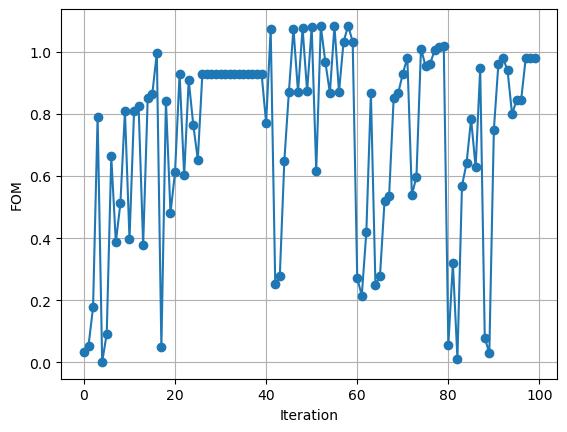

In [15]:
plt.figure()
plt.plot(evaluation_history, "o-")
plt.grid(True)
plt.xlabel("Iteration")
plt.ylabel("FOM")
plt.show()

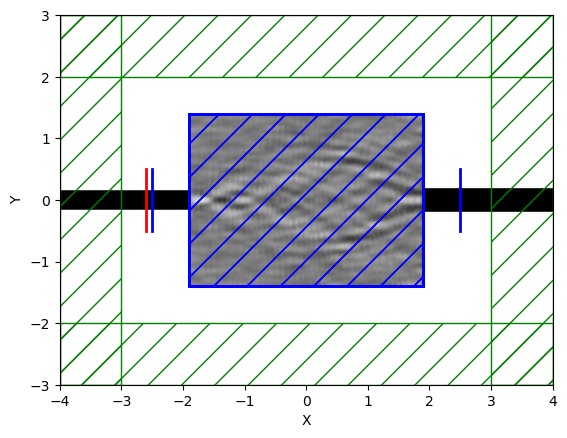

In [16]:
opt.plot2D(True)
plt.show()

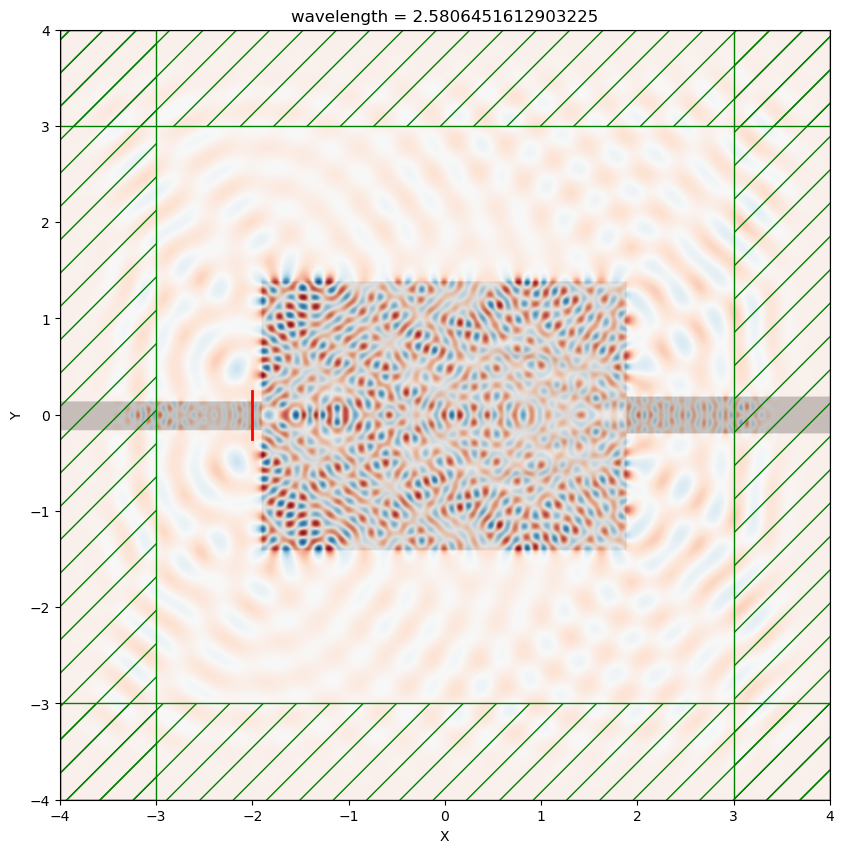

In [17]:
opt.sim = mp.Simulation(
    cell_size=mp.Vector3(8, 8),
    boundary_layers=pml_layers,
    geometry=geometry,
    sources=source,
    default_material=mp.air,
    resolution=resolution,
)
frec = 1/0.3875

wg_y = 0.5  # 도파관 두께(너 코드에 맞게)
src = mp.GaussianSource(frequency=fcen, fwidth=fwidth)

source = [mp.EigenModeSource(
    src,
    center=mp.Vector3(-2, 0, 0),          # 도파관 안쪽
    size=mp.Vector3(0, wg_y, 0),          # 단면을 덮게 (x방향 진행이면 x=0)
    direction=mp.X,                       # 진행방향
    eig_band=1,
    eig_match_freq=True,
    component=mp.Ez
)]
opt.sim.change_sources(source)

plt.figure(figsize=(16, 10))
plt.title('wavelength = '+str(frec))
opt.sim.run(until=180)
opt.sim.plot2D(fields=mp.Ez)
opt.sim.reset_meep()